In [10]:
import numpy as np

import bot
import state
import physics
import presets
import nn
import scoring
import curling_nn
from constants import center_of_target_house, house_outer_circle_radius, STONE_RADIUS_M
import dataset


import logging

logging.basicConfig(level=logging.ERROR, format="%(message)s")
logger = logging.getLogger(__name__)
logging.getLogger('matplotlib.font_manager').setLevel(logging.WARNING)

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
neural_network = curling_nn.ValueNetwork(seed=0, num_stones_per_side=5)
loss_function = nn.CrossEntropyLoss()

In [ ]:
states = presets.random_sheet_states(
  team1=5,
  team2=5,
  num_sims=1_000_000,
)
num_stones_per_side = 5

data = curling_nn.InputFeatures.create_score_match_dataset_from_sheet_states(
  states, num_stones_per_side
)


In [17]:
validation_states = presets.random_sheet_states(
  team1=5,
  team2=5,
  num_sims=200_000,
)
validation_data = curling_nn.InputFeatures.create_score_match_dataset_from_sheet_states(
  validation_states, num_stones_per_side
)

## categorical score predictor

In [ ]:
losses = []
num_points_per_batch = 100
num_iters = 10

for i in range(num_iters):
    losses.append(
        neural_network.get_average_loss_batched(
            data.input_features, data.answers, loss_function
        )
    )
    lr = 1 * 0.5 * (1 + np.cos(np.pi * i / num_iters))
    for batch in data.shuffle_batches(num_points_per_batch, seed=None):
        neural_network.train_batched(
            batch,
            loss_function,
            lr,
            0,
        )
        
losses.append(
        neural_network.get_average_loss_batched(
            data.input_features, data.answers, loss_function
        )
    )
    

In [18]:
validation_pred = neural_network.run(validation_data.input_features[:,:,None])

In [19]:
validation_r2 = 1 - ((validation_data.answers - validation_pred[:,:,0]) ** 2).sum() / (validation_data.answers ** 2).sum()

In [20]:
validation_r2

np.float64(0.8511919590766732)

Loaded backend module://matplotlib_inline.backend_inline version unknown.
Loaded backend module://matplotlib_inline.backend_inline version unknown.


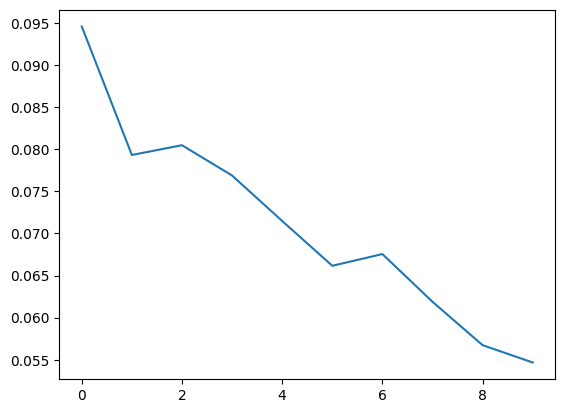

In [21]:
plt.plot(losses)

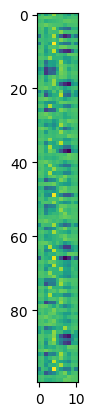

In [40]:
plt.imshow(neural_network.run(data.input_features[:, :, None])[:100,:,0])

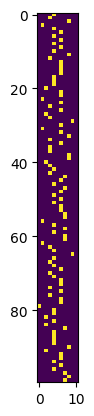

In [41]:
plt.imshow(data.answers[:100,:])

## predicting from second to last state

In [42]:
num_stones_per_side = 3

In [43]:
loss_function = nn.SquaredErrorLoss()

In [45]:
policy = bot.ArgmaxRandomThrowPolicy.max_single_turn_score(
    n_throws_per_state=100, random_action_prob=0.01
)

games = bot.run_games(
    num_sims=1_000,
    num_stones_per_side=3,
    first_player=policy,
    second_player=policy,
    seed=0,
)

In [46]:
first_player_scores = scoring.get_net_score_for_team(games[-1], 0)

In [47]:
data = dataset.TrainingData.curling(
    games[-2:],
    throws_remaining_by_team=[(0, 1), (0, 0)],
    final_scores=[first_player_scores]*2,
    seed=1,
    normalizer=None
)

In [48]:
losses = []
num_points_per_batch = 100
num_iters = 200

neural_network = init_base_nn(
    num_stones_per_side=num_stones_per_side,
    hidden_layer_size=20,
    output_layer_size=1,
    rng=np.random.default_rng(42),
)

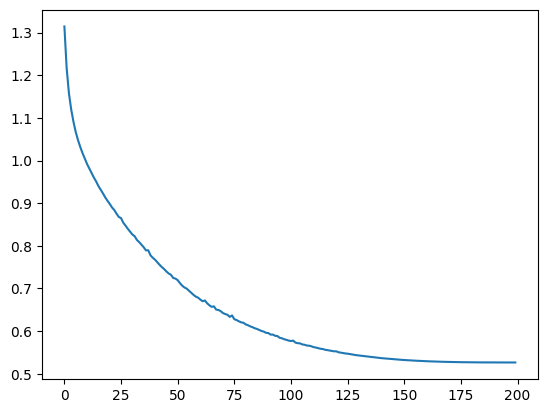

In [49]:
for i in range(num_iters):
    lr = .01 * 0.5 * (1 + np.cos(np.pi * i / num_iters))
    for batch in data.shuffle_batches(num_points_per_batch, seed=None):
        neural_network.train_batched(
            batch,
            loss_function,
            lr,
            0,
        )

    losses.append(
        neural_network.get_average_loss_batched(
            data.input_features, data.answers, loss_function
        )
    )

plt.plot(losses)